In [1]:
import numpy as np
import matplotlib as mpl
import os
import matplotlib.pyplot as plt
import numpy.ma as ma
from scipy import stats
import xarray as xr
import commondefs as myF
nm = 12
plt.rcParams.update({'font.size': 10})

In [2]:
# trends from historical+ssp245 runs - first ensemble member
model_ds = xr.open_dataset('../processed_netcdf/processed_CMIP6_sia_ssp245_r1_updated.nc').sel(year=slice('1979','2018'))
model_ds = myF.add_trend_stats_to_ds (model_ds, model_ds.sia_sh, 'sia_sh')
model_ds = myF.add_trend_stats_to_ds (model_ds, model_ds.gmst, 'gmst')


In [3]:
obs_ds = xr.open_dataset('../processed_netcdf/processed_OBS_sia_1979-2018.nc').sel(year=slice('1979','2018'))
obs_ds = myF.add_trend_stats_to_ds (obs_ds, obs_ds.sia_sh, 'sia_sh')

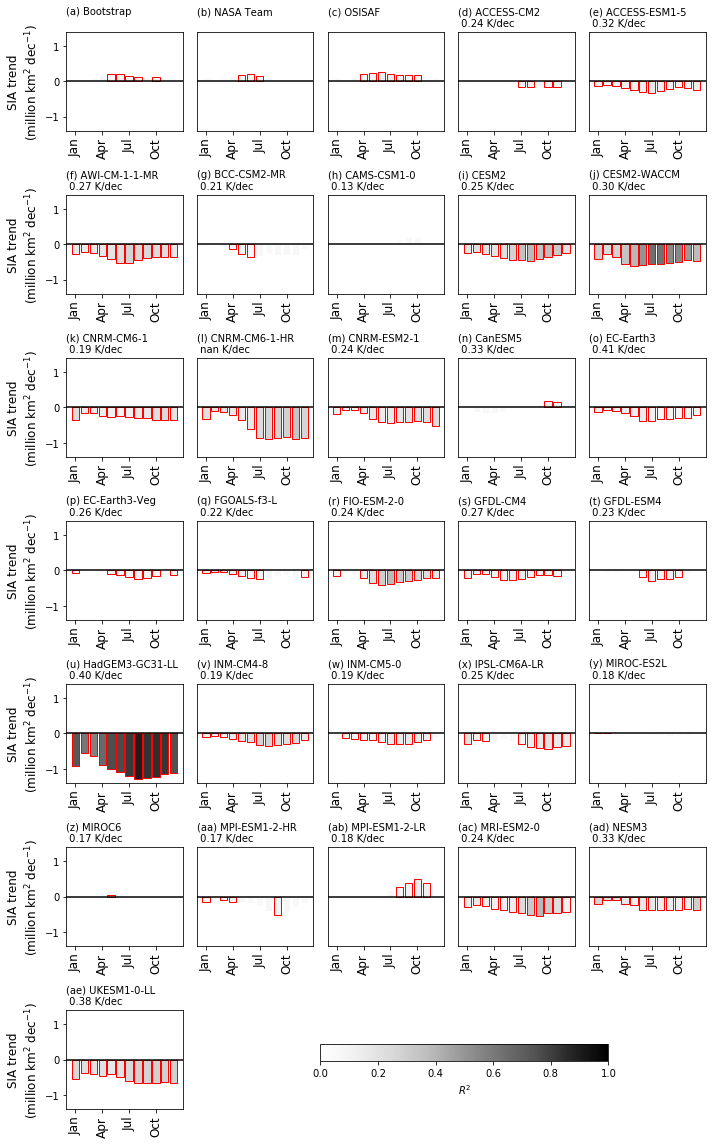

In [4]:

colours = plt.cm.Greys(np.linspace(0,1,2500))
fig = plt.figure(figsize=(10,16))
for n in range(len(model_ds.name)+len(obs_ds.name)):
    ax = plt.subplot(7,5,n+1)
    if n < 3:
        for m in range(nm):
            
            pval = obs_ds.sia_sh_p_value.isel(name=n).isel(month=m).values
            linc = 'white'
            if pval < 0.05:
                linc = 'red'
            slope = obs_ds.sia_sh_slope.isel(name=n).isel(month=m)
            err = obs_ds.sia_sh_std_error.isel(name=n).isel(month=m)
            ratio = abs(slope/err)
            
            ax.bar(m,10.*slope, edgecolor=linc, facecolor = colours[int(100*ratio)] )
        name = (str(obs_ds.isel(name=n).name.values)).split('_')[0]
        gmst_trend = ''
    
    else:
        for m in range(nm):
            pval = model_ds.sia_sh_p_value.isel(name=n-3).isel(month=m).values
            linc = 'white'
            if pval < 0.05:
                linc = 'red'
                
            slope = model_ds.sia_sh_slope.isel(name=n-3).isel(month=m)
            err = model_ds.sia_sh_std_error.isel(name=n-3).isel(month=m)
            ratio = abs(slope/err)
          
            ax.bar(m,10.*slope,edgecolor=linc,facecolor = colours[int(100*ratio)] )
            
        name = (str(model_ds.isel(name=n-3).name.values)).split('_')[0]
        gmst_trend = '{:.2f}'.format( 10.*model_ds['gmst_slope'].isel(name=n-3).values )+' K/dec'
        
    if n in [0,5,10,15,20,25,30]:
        plt.ylabel('SIA trend\n(million km$^2$ dec$^{-1}$)',fontsize=12) 
    else:
        ax.set_yticks([])
    ax.set_title(myF.alphabet[n]+' '+name+'\n '+gmst_trend,fontsize=10,loc='left')
    ax.axhline(y=0,c='black')
    ax.set_xticks(np.arange(nm)[::3])
    ax.set_xticklabels(myF.months[::3],rotation='vertical',fontsize=12)
    ax.set_ylim([-1.4,1.4])

    plt.tight_layout()

ax2  = fig.add_axes([0.45, 0.075, 0.4, 0.015])
cmap = mpl.cm.Greys
norm = mpl.colors.Normalize(vmin=0, vmax=1)
cb1 = mpl.colorbar.ColorbarBase(ax2, cmap=cmap, norm=norm,orientation='horizontal')
cb1.set_label('$R^2$')
fig.savefig('figS6',bbox_inches='tight',dpi=600)
plt.show()
plt.close()



 P=\lim _{T\to \infty }{\frac {1}{T}}\int _{0}^{T}|x(t)|^{2}\,dt

In [18]:
for m in range(nm):

    testdata = obs_ds.sia_sh[1,:,m]
    xdata = np.arange(len(testdata))

    ydata = testdata[~np.isnan(testdata)]
    xdata = xdata[~np.isnan(testdata)]
    
    slope, intercept, r_value, p_value, std_err = stats.linregress(xdata,ydata )
    fitdata = slope*xdata + intercept

    power_signal = (1/len(xdata))*np.sum(np.square(np.abs(fitdata))) #slope*xdata
    power_noise = (1/len(xdata))*np.sum(np.square(np.abs(ydata - fitdata)))
    ratio = power_signal/power_noise
    print(m,ratio.values)

0 55.667779602173574
1 49.42527083872435
2 44.2176707845042
3 69.98216913754156
4 196.534206597819
5 424.6196197661984
6 964.0611388522082
7 1715.1757301252326
8 1222.6995408334446
9 1088.2170002479293
10 513.6914944779413
11 126.80187027635111


0 0.009015104687786232 1.4316620380235543 0.019821352854102477 0.16063422074404984
1 0.006712417761622132 1.679812833399021 0.023008975959806603 0.10119843649147309
2 0.010016977847441348 1.7744007569506248 0.024304579384078037 0.08400935954414814
3 0.016573825616102954 1.9648024235356525 0.026912576705004194 0.056779730487885406
4 0.01837585719829536 2.338597675209378 0.03203257923662411 0.02471771341667221
5 0.02060066002618529 2.866075614519165 0.039257626565467954 0.006739236923290968
6 0.014240094509077416 2.465493772106531 0.033770718858400835 0.018312327843022794
7 0.009449058820554457 1.9741259407188854 0.02704028413672787 0.05566911960140834
8 0.006750245736941009 1.1547540859929768 0.015817065137154782 0.2554013797862205
9 0.006875120513427499 1.1501183274233489 0.01575356755256483 0.2572818846980519
10 -0.0020521939568701447 -0.28541161953646943 -0.003909381427498695 0.776878776047538
11 0.008117814277335253 0.9299473665869101 0.012903050263123078 0.35842627770464375


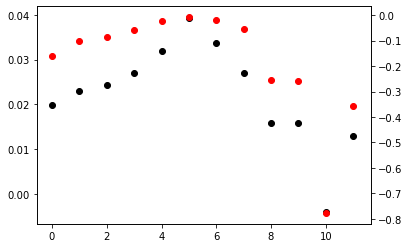

In [6]:
fig, ax = plt.subplots(1)
for m in range(nm):

    testdata = obs_ds.sia_sh[1,:,m]
    xdata = np.arange(len(testdata))

    ydata = testdata[~np.isnan(testdata)]
    xdata = xdata[~np.isnan(testdata)]
    
    slope, intercept, r_value, p_value, std_err = stats.linregress(xdata,ydata )
    fitdata = slope*xdata + intercept

    esterror = ydata - fitdata
    sse = np.sum(np.square(esterror))
    sigma_e = np.sqrt(sse/(len(xdata)-2))
    print(m,slope,slope/std_err,slope/sigma_e.values,p_value)
    ax.scatter(m,slope/sigma_e.values,c='k')
    if m==0:
        ax2 = ax.twinx()
    ax2.scatter(m,-p_value,c='r')
plt.show()
plt.close()

In [7]:
for m in range(nm):

    testdata = obs_ds.sia_sh[1,:,m].values
    xdata = np.arange(len(testdata))
    ydata = testdata[~np.isnan(testdata)]
    xdata = xdata[~np.isnan(testdata)]
    
    slope, intercept, r_value, p_value, std_err = stats.linregress(xdata,ydata )
  
    print(np.mean(ydata),np.std(ydata)>40.*slope)

3.3036329914362 True
1.9975218065119726 True
2.6687080428004264 True
5.017732818126679 False
7.835694592998874 False
10.536790659825007 False
12.759998508422605 False
14.105238413426184 False
14.544845928748448 True
14.031820010369824 True
11.596380124489468 True
6.899825071874388 True


In [8]:
slope, intercept, r_value, p_value, std_err

(0.008117814277335253,
 6.739133978999957,
 0.1511264647766501,
 0.35842627770464375,
 0.008729326593105187)

In [9]:

slope # 10^6 km^2/yr

0.008117814277335253

In [10]:

sse

<xarray.DataArray 'sia_sh' ()>
array(14.64519532)
Coordinates:
    month    int64 12
    name     <U9 'NASA Team'

In [11]:
sigma_e

<xarray.DataArray 'sia_sh' ()>
array(0.62913917)
Coordinates:
    month    int64 12
    name     <U9 'NASA Team'

In [12]:
slope/sigma_e

<xarray.DataArray 'sia_sh' ()>
array(0.01290305)
Coordinates:
    month    int64 12
    name     <U9 'NASA Team'